# 00 — Collecte des contours des communes de Dakar (OpenStreetMap)

**Ce que fait ce notebook**
1. Télécharge via l'API Overpass les limites administratives OSM de la région de Dakar : les départements (`admin_level=5`) et les communes d'arrondissement (`admin_level=8`).
2. Reconstruit les polygones et les enregistre **tels quels** dans `data/raw/`.
3. Télécharge le trait de côte OSM et **retire la partie en mer** des communes, car les limites OSM débordent sur l'océan.
4. Rattache chaque commune à son département et marque les zones prioritaires du chantier 1.

**Fichiers produits**

| Fichier | Contenu |
|---|---|
| `data/raw/osm_limites_admin_dakar_overpass.json` | réponse brute d'Overpass (limites) |
| `data/raw/osm_trait_de_cote_dakar_overpass.json` | réponse brute d'Overpass (côte) |
| `data/raw/communes_dakar_osm.geojson` | polygones OSM reconstruits, non modifiés (débordent en mer) |
| `data/processed/communes_dakar_terre.geojson` | **fichier à utiliser dans la suite** : communes découpées sur la terre ferme + département + zone prioritaire |

Aucun compte ni clé API n'est nécessaire.

In [1]:
from pathlib import Path
import json
import time

import requests
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point, box
from shapely.ops import polygonize, unary_union, linemerge

# Racine du projet : ce notebook est dans notebooks/, donc on remonte d'un niveau
PROJET = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = PROJET / "data" / "raw"
PROCESSED = PROJET / "data" / "processed"
OUTPUTS = PROJET / "outputs"
for d in (RAW, PROCESSED, OUTPUTS):
    d.mkdir(parents=True, exist_ok=True)

# Systèmes de coordonnées
CRS_GPS = "EPSG:4326"      # latitude/longitude (degrés), pour stocker et cartographier
CRS_METRES = "EPSG:32628"  # UTM zone 28N (mètres), pour calculer surfaces, distances, pentes

print("Dossier projet :", PROJET)

Dossier projet : C:\Users\Administrateur\Documents\dakar-risque-inondation


## 1. Fonction d'appel à Overpass

Le serveur public `overpass-api.de` est souvent saturé (erreur 504). La fonction essaie donc plusieurs serveurs et réessaie après une pause.

In [2]:
SERVEURS_OVERPASS = [
    "https://overpass-api.de/api/interpreter",
    "https://overpass.private.coffee/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter",
]

def requete_overpass(requete, tentatives=3, pause=20):
    """Envoie une requête Overpass QL et renvoie le JSON. Essaie plusieurs serveurs."""
    derniere_erreur = None
    for essai in range(tentatives):
        for url in SERVEURS_OVERPASS:
            try:
                r = requests.post(url, data={"data": requete},
                                  headers={"User-Agent": "dakar-risque-inondation/0.1"},
                                  timeout=300)
                if r.ok:
                    print(f"OK via {url}")
                    return r.json()
                print(f"{url} -> HTTP {r.status_code}")
            except requests.RequestException as e:
                print(f"{url} -> {type(e).__name__}")
                derniere_erreur = e
        print(f"Nouvelle tentative dans {pause} s...")
        time.sleep(pause)
    raise RuntimeError(f"Overpass indisponible après {tentatives} tentatives : {derniere_erreur}")

## 2. Téléchargement des limites administratives

`rel(2892079)` est la relation OSM « Région de Dakar ». On demande toutes les limites de niveau 5 (départements) et 8 (communes d'arrondissement) qui s'y trouvent. `out geom` renvoie directement les coordonnées des contours.

In [3]:
ID_OSM_REGION_DAKAR = 2892079

requete_limites = f"""[out:json][timeout:180];
rel({ID_OSM_REGION_DAKAR});map_to_area->.region;
( rel["boundary"="administrative"]["admin_level"~"^(5|8)$"](area.region); );
out geom;"""

brut_limites = requete_overpass(requete_limites)
fichier_brut_limites = RAW / "osm_limites_admin_dakar_overpass.json"
fichier_brut_limites.write_text(json.dumps(brut_limites, ensure_ascii=False), encoding="utf-8")
print(len(brut_limites["elements"]), "relations téléchargées ->", fichier_brut_limites.name)

https://overpass-api.de/api/interpreter -> HTTP 504


https://overpass.private.coffee/api/interpreter -> HTTP 504


OK via https://overpass.kumi.systems/api/interpreter
58 relations téléchargées -> osm_limites_admin_dakar_overpass.json


## 3. Reconstruction des polygones

Dans OSM, une commune est une *relation* composée de segments de contour (*ways*), avec le rôle `outer` (bord extérieur) ou `inner` (trou). On recolle les segments pour obtenir des polygones.

In [4]:
def relation_vers_polygone(relation):
    exterieur, interieur = [], []
    for m in relation["members"]:
        if m["type"] != "way" or "geometry" not in m:
            continue
        ligne = LineString([(p["lon"], p["lat"]) for p in m["geometry"]])
        (interieur if m.get("role") == "inner" else exterieur).append(ligne)
    poly = unary_union(list(polygonize(unary_union(exterieur))))
    if interieur:
        poly = poly.difference(unary_union(list(polygonize(unary_union(interieur)))))
    return poly

limites = gpd.GeoDataFrame(
    [{"osm_id": e["id"],
      "nom": e["tags"].get("name"),
      "admin_level": int(e["tags"]["admin_level"]),
      "wikidata": e["tags"].get("wikidata"),
      "geometry": relation_vers_polygone(e)}
     for e in brut_limites["elements"]],
    crs=CRS_GPS,
)
print("Polygones invalides :", (~limites.is_valid).sum(), "| vides :", limites.is_empty.sum())

fichier_communes_raw = RAW / "communes_dakar_osm.geojson"
limites.to_file(fichier_communes_raw, driver="GeoJSON")
print("Enregistré :", fichier_communes_raw)
limites.groupby("admin_level").size().rename("nombre")

Polygones invalides : 0 | vides : 0


Enregistré : C:\Users\Administrateur\Documents\dakar-risque-inondation\data\raw\communes_dakar_osm.geojson


admin_level
5     5
8    53
Name: nombre, dtype: int64

## 4. Rattachement de chaque commune à son département

On teste dans quel département tombe un point situé à l'intérieur de chaque commune. `representative_point` est toujours dans le polygone, contrairement au centroïde.

In [5]:
departements = limites[limites.admin_level == 5][["nom", "geometry"]].rename(columns={"nom": "departement"})
departements["departement"] = departements["departement"].str.replace("Département de ", "", regex=False)

communes = limites[limites.admin_level == 8].drop(columns="admin_level").copy()
points = communes.copy()
points["geometry"] = communes.representative_point()
jointure = gpd.sjoin(points, departements, how="left", predicate="within")
communes["departement"] = jointure["departement"]

# Nom court sans le préfixe "Commune de"
communes["commune"] = (communes["nom"]
                       .str.replace(r"^(Commune (de |du |d')|Communauté rurale de )", "", regex=True)
                       .str.strip())
print("Communes sans département :", communes["departement"].isna().sum())
communes.groupby("departement")["commune"].apply(lambda s: ", ".join(sorted(s))).to_frame()

Communes sans département : 0


,commune
departement,
Dakar,"Biscuiterie, Cambérène, Dakar-Plateau, Dieuppe..."
Guédiawaye,"Golf Sud, Medina Gounass, Ndiarème Limamoulaye..."
Keur Massar,"Jaxaay - Parcelles, Keur Massar Nord, Keur Mas..."
Pikine,"Dalifort, Diamaguène-Sicap Mbao, Djidah Thiaro..."
Rufisque,"Bambylor, Bargny, Diamniadio, Rufisque Est, Ru..."


## 5. Retrait de la partie en mer

**Problème constaté :** sur la côte nord (Guédiawaye, Yeumbeul Nord, Malika, Cambérène…) et au sud de Rufisque, les limites OSM sont des lignes droites tracées **en mer**. Certaines communes sont à plus de 50 % en mer. Si on les garde, l'altitude moyenne (étape 5) inclurait l'océan à 0 m et ces communes paraîtraient faussement « basses ».

**Méthode :** on télécharge le trait de côte OSM (`natural=coastline`) et on découpe le rectangle d'étude en morceaux le long de la côte. Par convention OSM, **la terre est toujours à gauche** du sens de tracé de la côte, ce qui permet de savoir quels morceaux sont de la terre.

In [6]:
O, S, E, N = communes.total_bounds + [-0.02, -0.02, 0.02, 0.02]
requete_cote = f"""[out:json][timeout:180];
way["natural"="coastline"]({S},{O},{N},{E});
out geom;"""
brut_cote = requete_overpass(requete_cote)
(RAW / "osm_trait_de_cote_dakar_overpass.json").write_text(json.dumps(brut_cote, ensure_ascii=False), encoding="utf-8")

segments_cote = [LineString([(p["lon"], p["lat"]) for p in e["geometry"]]) for e in brut_cote["elements"]]
rectangle = box(O, S, E, N)
cote = linemerge(unary_union(segments_cote)).intersection(rectangle)
morceaux = list(polygonize(unary_union([rectangle.exterior, cote])))

# Pour chaque petit tronçon de côte : un point juste à gauche (terre) et un juste à droite (mer)
tests = []
for seg in segments_cote:
    c = list(seg.coords)
    for (x1, y1), (x2, y2) in zip(c[:-1], c[1:]):
        L = ((x2 - x1) ** 2 + (y2 - y1) ** 2) ** 0.5
        if L == 0:
            continue
        mx, my, d = (x1 + x2) / 2, (y1 + y2) / 2, 1e-5
        tests.append((Point(mx - d * (y2 - y1) / L, my + d * (x2 - x1) / L),
                      Point(mx + d * (y2 - y1) / L, my - d * (x2 - x1) / L)))

morceaux_terre = [m for m in morceaux
                  if sum(m.contains(g) for g, _ in tests) > sum(m.contains(dr) for _, dr in tests)]
terre = unary_union(morceaux_terre)
print(f"{len(segments_cote)} tronçons de côte ; {len(morceaux)} morceaux dont {len(morceaux_terre)} de terre")

surface_avant = communes.to_crs(CRS_METRES).area / 1e6
communes["geometry"] = communes.intersection(terre)
communes["surface_km2"] = (communes.to_crs(CRS_METRES).area / 1e6).round(3)
communes["pct_mer_retire"] = (100 * (surface_avant - communes["surface_km2"]) / surface_avant).round(1)
communes.sort_values("pct_mer_retire", ascending=False)[["commune", "departement", "surface_km2", "pct_mer_retire"]].head(15)

https://overpass-api.de/api/interpreter -> HTTP 504


https://overpass.private.coffee/api/interpreter -> HTTP 504


https://overpass.kumi.systems/api/interpreter -> HTTP 504
Nouvelle tentative dans 20 s...


OK via https://overpass-api.de/api/interpreter


97 tronçons de côte ; 21 morceaux dont 20 de terre


,commune,departement,surface_km2,pct_mer_retire
27,Cambérène,Dakar,1.976,76.5
32,Ngor,Dakar,4.370,66.8
6,Ndiarème Limamoulaye,Guédiawaye,1.304,60.7
4,Wakhinane Nimzatt,Guédiawaye,4.350,54.1
10,Malika,Keur Massar,10.860,50.3
5,Sam Notaire,Guédiawaye,2.706,43.8
29,Parcelles Assainies,Dakar,3.895,40.4
31,Yoff,Dakar,14.592,34.1
52,Thiaroye-sur-Mer,Pikine,3.611,30.2
7,Golf Sud,Guédiawaye,4.265,30.2


In [7]:
# Contrôle : communes devenues vides ou minuscules après découpage
communes[communes["surface_km2"] < 0.1][["commune", "surface_km2", "pct_mer_retire"]]

,commune,surface_km2,pct_mer_retire


## 6. Zones prioritaires du chantier 1

Correspondance retenue, **à valider** :

| Zone demandée | Ce qu'on prend | Pourquoi |
|---|---|---|
| **Pikine** | toutes les communes du **département** de Pikine | « Pikine » désigne couramment le département ; seules 3 communes portent le nom (Pikine Est, Nord, Ouest) |
| **Guédiawaye** | toutes les communes du **département** de Guédiawaye | Guédiawaye n'existe pas comme commune unique |
| **Yeumbeul** | Yeumbeul Nord + Yeumbeul Sud | rattachées depuis 2021 au département de Keur Massar |
| **Médina** | commune de Médina | — |
| **Grand Yoff** | commune de Grand Yoff | — |

**On garde toutes les communes de la région** dans le fichier. Le score de risque (étape 6) compare chaque commune aux autres ; avec seulement les ~20 communes prioritaires, la référence serait trop étroite. La colonne `zone_prioritaire` sert à filtrer ou mettre en valeur sur la carte.

In [8]:
def zone_prioritaire(ligne):
    if ligne["departement"] == "Pikine":
        return "Pikine"
    if ligne["departement"] == "Guédiawaye":
        return "Guédiawaye"
    if ligne["commune"] in ("Yeumbeul Nord", "Yeumbeul Sud"):
        return "Yeumbeul"
    if ligne["commune"] == "Médina":
        return "Médina"
    if ligne["commune"] == "Grand Yoff":
        return "Grand Yoff"
    return None

communes["zone_prioritaire"] = communes.apply(zone_prioritaire, axis=1)
communes["prioritaire"] = communes["zone_prioritaire"].notna()

(communes[communes.prioritaire]
 .sort_values(["zone_prioritaire", "commune"])
 [["zone_prioritaire", "commune", "departement", "surface_km2", "pct_mer_retire"]]
 .reset_index(drop=True))

,zone_prioritaire,commune,departement,surface_km2,pct_mer_retire
0,Grand Yoff,Grand Yoff,Dakar,6.244,-0.0
1,Guédiawaye,Golf Sud,Guédiawaye,4.265,30.2
2,Guédiawaye,Medina Gounass,Guédiawaye,0.733,0.0
3,Guédiawaye,Ndiarème Limamoulaye,Guédiawaye,1.304,60.7
4,Guédiawaye,Sam Notaire,Guédiawaye,2.706,43.8
5,Guédiawaye,Wakhinane Nimzatt,Guédiawaye,4.350,54.1
6,Médina,Médina,Dakar,2.341,0.0
7,Pikine,Dalifort,Pikine,2.449,-0.0
8,Pikine,Diamaguène-Sicap Mbao,Pikine,7.486,7.3
9,Pikine,Djidah Thiaroye Kaw,Pikine,1.887,0.0


## 7. Enregistrement et carte de contrôle

In [9]:
colonnes = ["osm_id", "commune", "departement", "zone_prioritaire", "prioritaire",
            "surface_km2", "pct_mer_retire", "wikidata", "geometry"]
communes = communes[colonnes].sort_values(["departement", "commune"]).reset_index(drop=True)

FICHIER_COMMUNES = PROCESSED / "communes_dakar_terre.geojson"
communes.to_file(FICHIER_COMMUNES, driver="GeoJSON")
print(f"{len(communes)} communes enregistrées dans {FICHIER_COMMUNES}")
print(f"dont {communes.prioritaire.sum()} en zone prioritaire")

53 communes enregistrées dans C:\Users\Administrateur\Documents\dakar-risque-inondation\data\processed\communes_dakar_terre.geojson
dont 21 en zone prioritaire


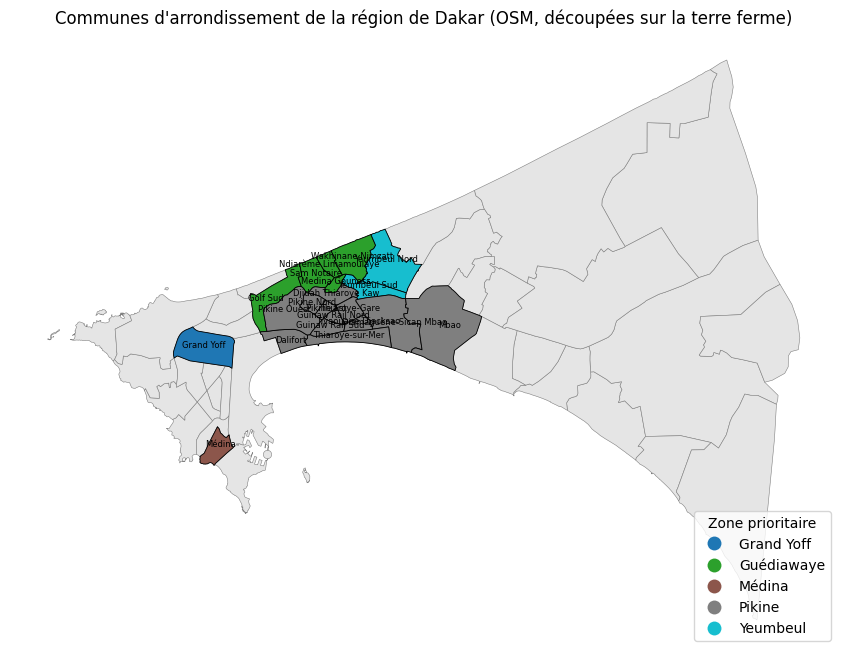

In [10]:
fig, ax = plt.subplots(figsize=(13, 8))
communes.plot(ax=ax, color="#e5e5e5", edgecolor="grey", linewidth=0.4)
communes[communes.prioritaire].plot(ax=ax, column="zone_prioritaire", categorical=True,
                                    legend=True, edgecolor="black", linewidth=0.6,
                                    legend_kwds={"loc": "lower right", "title": "Zone prioritaire"})
for _, c in communes[communes.prioritaire].iterrows():
    p = c.geometry.representative_point()
    ax.annotate(c.commune, (p.x, p.y), fontsize=6, ha="center")
ax.set_title("Communes d'arrondissement de la région de Dakar (OSM, découpées sur la terre ferme)")
ax.set_axis_off()
plt.savefig(OUTPUTS / "apercu_communes.png", dpi=150, bbox_inches="tight")
plt.show()

## Limites de ces données (à garder en tête)

- **Unité spatiale = commune d'arrondissement**, pas le quartier au sens populaire (Thiaroye Azur, Diamaguène…). OSM ne contient pas de découpage homogène des quartiers en dessous de la commune pour Dakar. Une commune fait 1 à 20 km² : **une commune « à risque » peut contenir des quartiers épargnés, et inversement.**
- **Limites non officielles** : ce sont des tracés de contributeurs OSM, pas le fichier de l'ANSD ou de la DTGC. Ils sont cohérents ici (pas de trou, pas de chevauchement), mais leur précision n'est pas garantie au mètre près.
- **Découpage administratif récent** : le département de Keur Massar a été créé en 2021 (Yeumbeul, Malika, Keur Massar). OSM le reflète, mais certaines données plus anciennes (population ANSD 2013, par exemple) utilisent l'ancien découpage, sous Pikine.
- **Trait de côte OSM** : sa précision est de quelques dizaines de mètres. Cela suffit pour retirer la mer, pas pour étudier l'érosion côtière.
- Les **plans d'eau intérieurs** (lac Rose, lac Mbeubeuss, Niayes) sont **conservés** dans les communes. C'est voulu, mais il faudra les distinguer des inondations à l'étape 4 : un lac permanent n'est pas de l'« eau stagnante ».